# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [21]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [22]:
csv_path = "../data/checker_submits.csv"
df = pd.read_csv(csv_path, parse_dates=["timestamp"])

In [23]:
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df.drop(axis=1, labels=['timestamp'], inplace=True)

In [24]:
one_hot_enc = OneHotEncoder()
ohe_array = one_hot_enc.fit_transform(df[['uid', 'labname']]).toarray()

ohe_df = pd.DataFrame(
    ohe_array,
    columns=one_hot_enc.get_feature_names(['uid', 'labname']),
    index=df.index
)

df = pd.concat([df, ohe_df], axis=1).drop(axis=1, labels=['uid', 'labname'])

In [25]:
std_scaler = StandardScaler()
df[['numTrials']] = std_scaler.fit_transform(df[['numTrials']])
df[['hour']] = std_scaler.fit_transform(df[['hour']])

In [26]:
df.to_csv('../data/dayofweek.csv', index=False)
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
acc = accuracy_score(df['dayofweek'], [df['dayofweek'].mode().iloc[0] for i in range(0, len(df['dayofweek']))])
print(f'Naive Solution accuracy: {acc}')

Naive Solution accuracy: 0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [28]:
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

In [29]:
logreg = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
logreg.fit(X, y)
acc = accuracy_score(y, logreg.predict(X))
print(f'Logistic Regression accuracy: {acc}')

Logistic Regression accuracy: 0.6215895610913404


In [30]:
def barh(importance, feature_names, top_n=10):
    if importance.ndim == 2:
        importance = np.abs(importance).sum(axis=0)
    else:
        importance = np.abs(importance)
    idx = np.argsort(importance)[-top_n:]
    plt.figure(figsize=(10, top_n * 0.5))
    plt.barh(range(top_n), importance[idx])
    plt.yticks(range(top_n), [feature_names[i] for i in idx])
    plt.gca().invert_yaxis()
    plt.show()

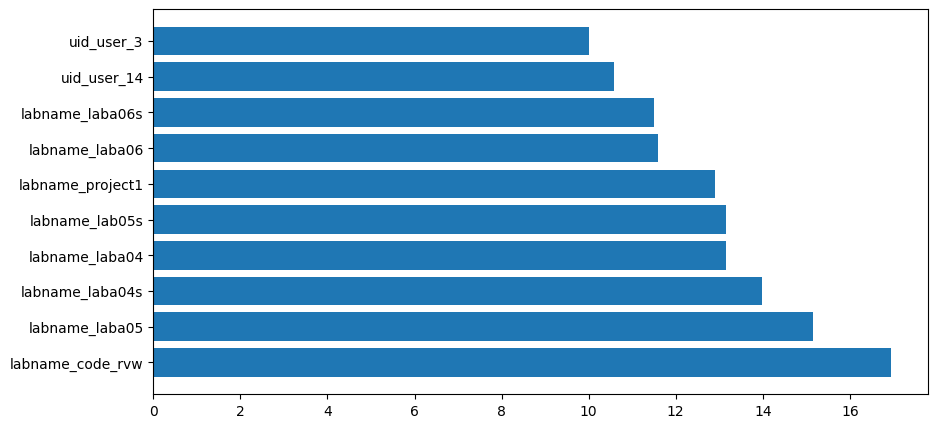

In [31]:
barh(logreg.coef_, X.columns.tolist(), top_n=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [32]:
svc = SVC(kernel='linear', probability=True, random_state=21)
svc.fit(X, y)
acc = accuracy_score(y, svc.predict(X))
print(f'SVC accuracy: {acc}')

SVC accuracy: 0.702846975088968


In [33]:
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    model = SVC(kernel=kernel, probability=True, random_state=21)
    model.fit(X, y)
    print(f'{kernel}: {accuracy_score(y, model.predict(X))}')

linear: 0.702846975088968
poly: 0.8594306049822064
rbf: 0.8558718861209964
sigmoid: 0.3997627520759193


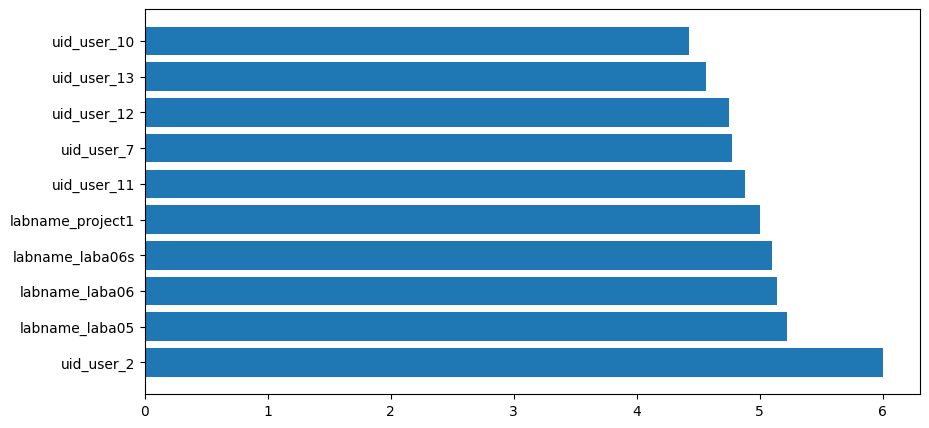

In [34]:
ovr_svc = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
ovr_svc.fit(X, y)
coefs = np.concatenate([est.coef_ for est in ovr_svc.estimators_])
barh(coefs, X.columns.tolist(), top_n=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [35]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X, y)
print('Decision Tree accuracy:', accuracy_score(y, tree.predict(X)))

Decision Tree accuracy: 0.5516014234875445


In [36]:
for depth in range (1, 15):
    tree_temp = DecisionTreeClassifier(max_depth=depth, random_state=21)
    tree_temp.fit(X, y)
    acc = accuracy_score(y, tree_temp.predict(X))
    print(f'max_depth={depth}: {acc}')

max_depth=1: 0.35765124555160144
max_depth=2: 0.4389086595492289
max_depth=3: 0.48991696322657174
max_depth=4: 0.5516014234875445
max_depth=5: 0.6109134045077106
max_depth=6: 0.6637010676156584
max_depth=7: 0.7064056939501779
max_depth=8: 0.7502965599051008
max_depth=9: 0.7846975088967971
max_depth=10: 0.8196915776986952
max_depth=11: 0.8499406880189798
max_depth=12: 0.8831553973902728
max_depth=13: 0.9104389086595492
max_depth=14: 0.9317912218268091


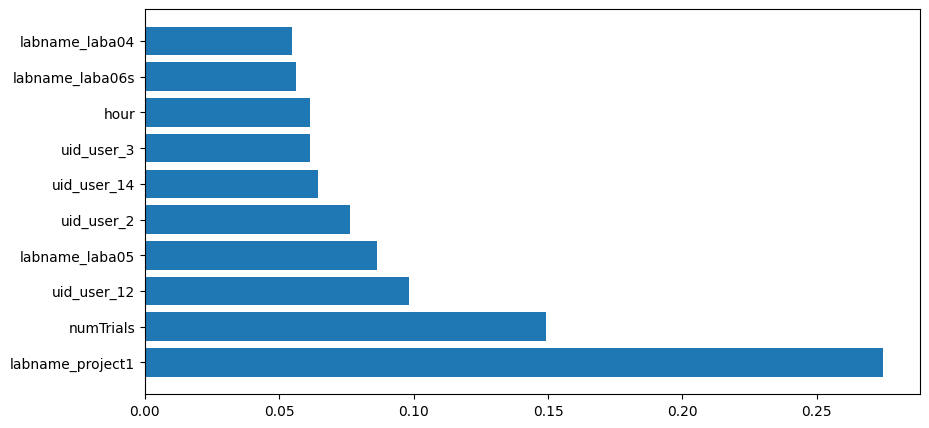

In [37]:
barh(tree.feature_importances_, X.columns.tolist(), top_n=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [38]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf.fit(X, y)
print('Random Forest baseline accuracy:', accuracy_score(y, rf.predict(X)))

Random Forest baseline accuracy: 1.0


In [39]:
for n in [50, 100, 200]:
    for d in [10, 15, 25, 30]:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=21)
        rf.fit(X, y)
        print(f'n_estimators={n}, max_depth={d}: {accuracy_score(y, rf.predict(X)):.4f}')

n_estimators=50, max_depth=10: 0.8701
n_estimators=50, max_depth=15: 0.9786
n_estimators=50, max_depth=25: 1.0000
n_estimators=50, max_depth=30: 1.0000
n_estimators=100, max_depth=10: 0.8855
n_estimators=100, max_depth=15: 0.9781
n_estimators=100, max_depth=25: 1.0000
n_estimators=100, max_depth=30: 1.0000
n_estimators=200, max_depth=10: 0.8778
n_estimators=200, max_depth=15: 0.9792
n_estimators=200, max_depth=25: 1.0000
n_estimators=200, max_depth=30: 1.0000


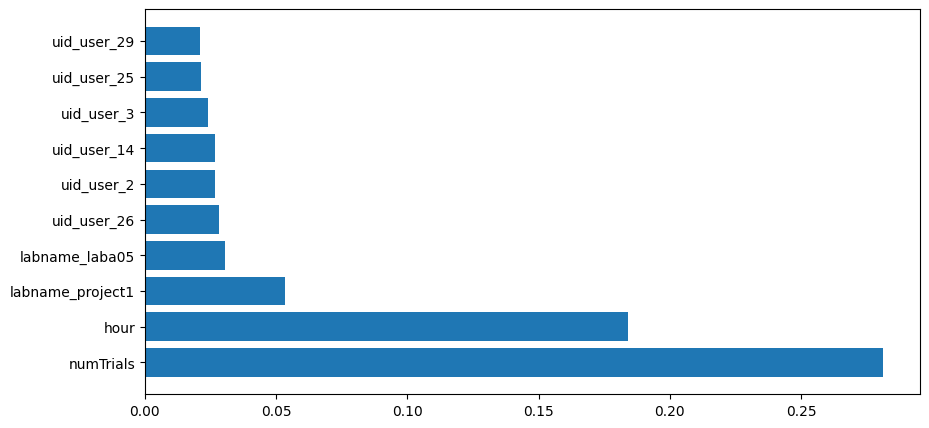

In [40]:
barh(rf.feature_importances_, X.columns.tolist(), top_n=10)